Importing required libraries

In [2]:
import pandas as pd
from sklearn.linear_model import LinearRegression, SGDRegressor, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    accuracy_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.svm import SVC


In [4]:
import pandas as pd

train_df = pd.read_csv('cicds_train.csv')
test_df = pd.read_csv('cicds_test.csv')

In [6]:
train_df.head()

,Flow Duration,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Min,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,...,PSH Flag Count,ACK Flag Count,Down/Up Ratio,Avg Fwd Segment Size,Init_Win_bytes_backward,Idle Mean,Idle Std,Idle Max,Idle Min,Attack_Type
0,169,40.0,0.0,56,23668.639050,56.333333,57.951129,118,3,3,...,0,0,1,40.0,-1,0.0,0.0,0,0,1
1,246,32.0,0.0,113,16260.162600,82.000000,140.296115,244,1,1,...,0,0,1,32.0,-1,0.0,0.0,0,0,0
2,31109,39.0,0.0,71,257.160307,4444.142857,11646.273500,30855,1,30863,...,0,0,1,39.0,-1,0.0,0.0,0,0,1
3,61975,46.0,0.0,174,64.542154,20658.333330,35775.220760,61968,3,4,...,0,0,1,46.0,-1,0.0,0.0,0,0,1
4,86684,6.0,0.0,6,46.144617,28894.666667,50043.566643,86680,1,0,...,0,1,3,6.0,253,0.0,0.0,0,0,1


In [8]:
TARGET_COLUMN = 'Attack_Type' 
FEATURE_COLUMNS = [col for col in train_df.columns if col != TARGET_COLUMN]

In [10]:
X_train = train_df[FEATURE_COLUMNS]
y_train = train_df[TARGET_COLUMN]
X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
print(f"Data loaded and prepared for {len(FEATURE_COLUMNS)} features and target '{TARGET_COLUMN}'.\n")

Data loaded and prepared for 36 features and target 'Attack_Type'.



In [16]:
train_df.shape

(2264594, 37)

In [18]:
print(train_df.describe())

        Flow Duration   Fwd Packet Length Mean   Fwd Packet Length Std  \
count    2.264594e+06             2.264594e+06            2.264594e+06   
mean     1.478706e+07             5.819231e+01            6.896143e+01   
std      3.365447e+07             1.861464e+02            2.813934e+02   
min     -1.300000e+01             0.000000e+00            0.000000e+00   
25%      1.550000e+02             6.000000e+00            0.000000e+00   
50%      3.131500e+04             3.400000e+01            0.000000e+00   
75%      3.185159e+06             5.000000e+01            2.616295e+01   
max      1.200000e+08             5.940857e+03            7.049469e+03   

        Bwd Packet Length Min   Flow Packets/s   Flow IAT Mean   Flow IAT Std  \
count            2.264594e+06     2.264594e+06    2.264594e+06   2.264594e+06   
mean             4.104709e+01     7.085470e+04    1.299546e+06   2.921029e+06   
std              6.892596e+01     2.543951e+05    4.515618e+06   8.052027e+06   
min      

In [20]:
print(f'Training data percentage:{(train_df.shape[0]/(train_df.shape[0]+test_df.shape[0]))*100}')
print(f'Testing data percentage:{(test_df.shape[0]/(train_df.shape[0]+test_df.shape[0]))*100}')

Training data percentage:79.99998586943427
Testing data percentage:20.00001413056572


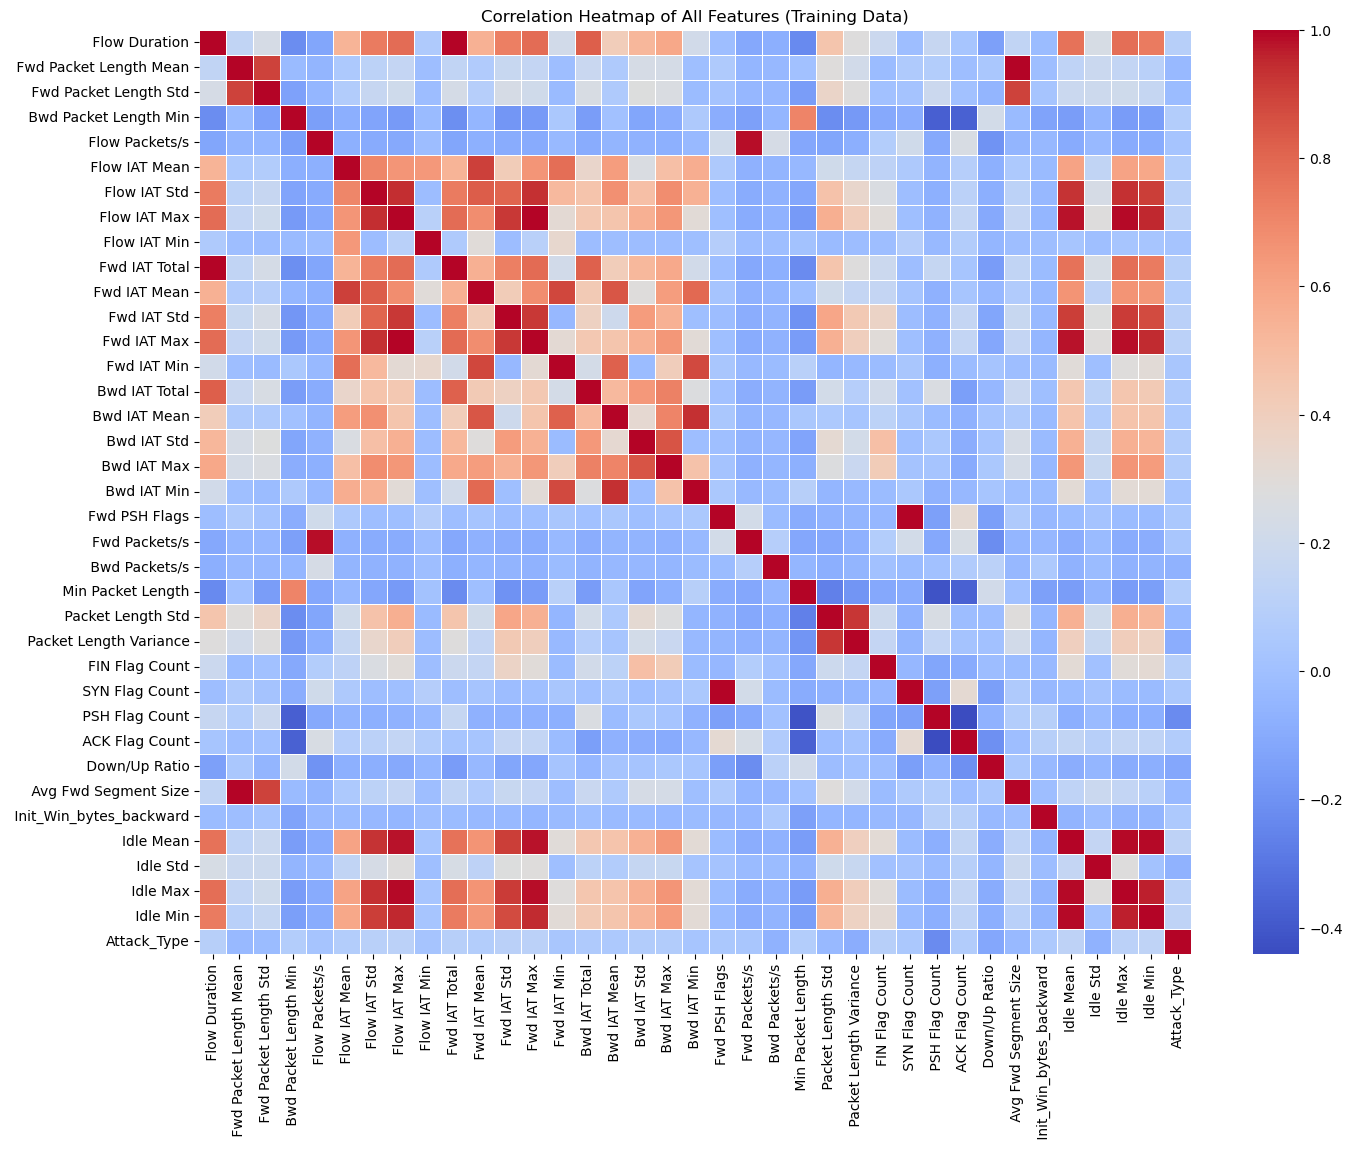

In [22]:
# Compute correlation matrix on training data
corr_matrix = train_df.corr()

# Plot heatmap
plt.figure(figsize=(16, 12))  # Large size for readability
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap of All Features (Training Data)')
plt.show()

In [24]:
models = {
    "Linear Regression (OLS)": LinearRegression(),
    
    "Gradient Descent (SGD)": SGDRegressor(
        max_iter=3000, 
        tol=1e-4, 
        random_state=42, 
        early_stopping=True, 
        validation_fraction=0.15,
        alpha=0.1  
    ),
    
    "Logistic Regression": LogisticRegression(
        max_iter=1000, 
        random_state=42,
        C=1.0  
    ),
    
    "Naïve Bayes (Gaussian)": GaussianNB(), 
    
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=300,
        min_samples_leaf=150,
        max_features='sqrt',
        ccp_alpha=0.002,
        random_state=42  
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=20,  
        max_depth=6,      
        min_samples_split=200,
        min_samples_leaf=100,
        max_features='sqrt',
        max_samples=0.4,  
        n_jobs=-1,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=50,     
        max_depth=4,          
        learning_rate=0.05,   
        subsample=0.6,
        colsample_bytree=0.6,
        min_child_weight=20,
        gamma=0.3,            
        reg_alpha=0.3,
        reg_lambda=1.5,       
        eval_metric='logloss',
        n_jobs=-1,
        random_state=42
    ),
    
    "SVM (RBF Kernel)": SVC(
        kernel='rbf',
        C=0.1,              
        gamma='scale',
        random_state=42
    )
}

In [26]:
results = {}

In [ ]:
for name, model in models.items():
    print(f"\n{'='*20} Training {name} {'='*20}")
    # ---------- Fit ----------
    if name in ["Linear Regression (OLS)", "Gradient Descent (SGD)"]:
        # Regressors → use scaled data
        model.fit(X_train_scaled, y_train)
        # Training predictions
        y_train_pred_cont = model.predict(X_train_scaled)
        y_train_pred = (y_train_pred_cont >= 0.5).astype(int)
        # Testing predictions
        y_pred_cont = model.predict(X_test_scaled)
        y_pred = (y_pred_cont >= 0.5).astype(int)
    else:
        # All classifiers → use scaled data (trees ignore it)
        model.fit(X_train_scaled, y_train)
        # Training predictions
        y_train_pred = model.predict(X_train_scaled)
        # Testing predictions
        y_pred = model.predict(X_test_scaled)
    
    # ---------- Metrics ----------
    # Training metrics
    train_acc = accuracy_score(y_train, y_train_pred)
    
    # Testing metrics
    cm   = confusion_matrix(y_test, y_pred)
    test_acc  = accuracy_score(y_test, y_pred)
    rep  = classification_report(y_test, y_pred, output_dict=True)
    
    # ---------- Store ----------
    results[name] = {
        "confusion_matrix": cm,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "classification_report": rep,
        "y_pred": y_pred
    }
    # ---------- Print ----------
    recall_attack = rep['1']['recall']
    print(f"Training Accuracy : {train_acc:.4f}")
    print(f"Testing Accuracy  : {test_acc:.4f}")
    print(f"Recall (Attack)   : {recall_attack:.4f}")
    print("Confusion Matrix:\n", cm)
    print("-" * 60)


==================== Training Linear Regression (OLS) ====================
Training Accuracy : 0.7347
Testing Accuracy  : 0.7347
Recall (Attack)   : 0.9393
Confusion Matrix:
 [[ 66624 127612]
 [ 22571 349342]]
------------------------------------------------------------

==================== Training Gradient Descent (SGD) ====================
Training Accuracy : 0.7269
Testing Accuracy  : 0.7271
Recall (Attack)   : 0.9344
Confusion Matrix:
 [[ 64124 130112]
 [ 24380 347533]]
------------------------------------------------------------

==================== Training Logistic Regression ====================
Training Accuracy : 0.7397
Testing Accuracy  : 0.7397
Recall (Attack)   : 0.9434
Confusion Matrix:
 [[ 67902 126334]
 [ 21041 350872]]
------------------------------------------------------------

==================== Training Naïve Bayes (Gaussian) ====================
Training Accuracy : 0.4645
Testing Accuracy  : 0.4640
Recall (Attack)   : 0.2430
Confusion Matrix:
 [[172284  2195

In [ ]:
n = len(results)
cols = 2
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
axes = axes.flatten() if n > 1 else [axes]

for idx, (name, res) in enumerate(results.items()):
    disp = ConfusionMatrixDisplay(res["confusion_matrix"],
                                  display_labels=['Normal', 'Attack'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    acc = res["test_accuracy"]  # ✅ Changed from "accuracy" to "test_accuracy"
    recall = res["classification_report"]['1']['recall']
    axes[idx].set_title(f"{name}\nAcc: {acc:.3f} | Rec: {recall:.3f}")

# Hide empty subplots
for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()